# Módulo 7 — Introducción a ARMA: ARMA(1,1) sobre retornos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
import warnings
warnings.filterwarnings("ignore")

def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.llf
    L2 = mod_2.llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv")
df_comp = raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True)
df_comp = df_comp.asfreq('B')
df_comp = df_comp.ffill()

df_comp['market_value'] = df_comp.ftse
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]
df['returns'] = df.market_value.pct_change(1)*100
df.head()

,market_value,returns
date,,
1994-01-07,3445.98,NaN
1994-01-10,3440.58,-0.156704
1994-01-11,3413.77,-0.779229
1994-01-12,3372.02,-1.222988
1994-01-13,3360.01,-0.356166


## AR(1) y MA(1) por separado, como referencia

In [3]:
model_ret_ar_1 = ARIMA(df.returns[1:], order=(1, 0, 0))
results_ret_ar_1 = model_ret_ar_1.fit()
model_ret_ma_1 = ARIMA(df.returns[1:], order=(0, 0, 1))
results_ret_ma_1 = model_ret_ma_1.fit()
print("AR(1)  AIC:", results_ret_ar_1.aic, " LL:", results_ret_ar_1.llf)
print("MA(1)  AIC:", results_ret_ma_1.aic, " LL:", results_ret_ma_1.llf)

AR(1)  AIC: 15865.497444689832  LL: -7929.748722344916
MA(1)  AIC: 15865.190017883862  LL: -7929.595008941931


## ARMA(1,1)

In [4]:
model_ret_ar_1_ma_1 = ARIMA(df.returns[1:], order=(1, 0, 1))
results_ret_ar_1_ma_1 = model_ret_ar_1_ma_1.fit()
results_ret_ar_1_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7916.500
Date:                Wed, 16 Sep 2026   AIC                          15841.000
Time:                        18:55:38   BIC                          15867.085
Sample:                    01-10-1994   HQIC                         15850.140
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.290      0.197      -0.010       0.048
ar.L1          0.7650      0.045     16.995      0.000       0.677       0.853
ma.L1         -0.8142      0.040    -20.187      0.000      -0.893      -0.735
sigma2         1.3718      0.014     98.110      0.000       1.344       1.399
===================================================================================
Ljung-Box (L1) (Q):                   2.06   Jarque-Bera (JB):              7488.92
Prob(Q):                              0.15   Prob(JB):                         0.00
Heteroskedasticity (H):               2.03   Skew:                            -0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
print("ARMA(1,1) vs AR(1): ", LLR_test(results_ret_ar_1, results_ret_ar_1_ma_1))
print("ARMA(1,1) vs MA(1): ", LLR_test(results_ret_ma_1, results_ret_ar_1_ma_1))

ARMA(1,1) vs AR(1):  0.0
ARMA(1,1) vs MA(1):  0.0


## ACF y PACF de los retornos (para decidir si merece la pena subir de orden)

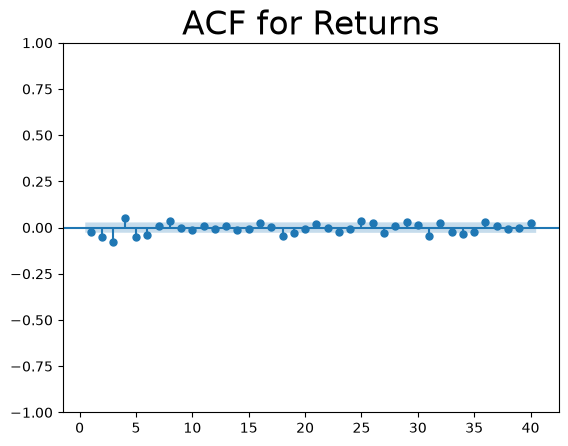

In [6]:
sgt.plot_acf(df.returns[1:], zero=False, lags=40)
plt.title("ACF for Returns", size=24)
plt.show()

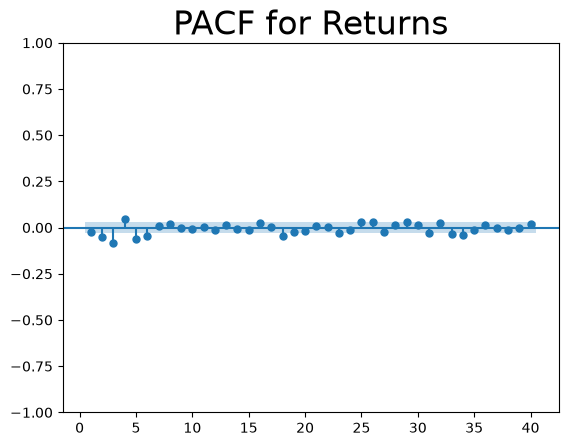

In [7]:
sgt.plot_pacf(df.returns[1:], zero=False, lags=40, method='ols')
plt.title("PACF for Returns", size=24)
plt.show()